# Base Model


In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch import nn
from torch.utils .data import Dataset, DataLoader, random_split
from torchvision.datasets import FashionMNIST

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
SEED = 42
set_seed(SEED)

In [3]:
train_dataset = FashionMNIST("./data",train=True,download=True,transform = transforms.ToTensor())
test_dataset = FashionMNIST("./data",train=False,download=True,transform = transforms.ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 7.96MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



In [4]:
train_ratio = 0.9
train_size = int(len(train_dataset)*train_ratio)
val_size = len(train_dataset)-train_size

train_subset, val_subset = random_split(train_dataset, [train_size,val_size])

train_loader = DataLoader(train_subset,batch_size=64, shuffle=True)

val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {len(train_subset)}")
print(f"Val size: {len(val_subset)}")
print(f"Test size: {len(test_dataset)}")

Train size: 54000
Val size: 6000
Test size: 10000


In [5]:
class MLP(nn.Module):
  def __init__(self,input_dims,hidden_dims, output_dims):
    super().__init__()
    self.layer1 = nn.Linear(input_dims,hidden_dims)
    self.layer2 = nn.Linear(hidden_dims,hidden_dims)
    self.layer3 = nn.Linear(hidden_dims,hidden_dims)
    self.layer4 = nn.Linear(hidden_dims,hidden_dims)
    self.layer5 = nn.Linear(hidden_dims,hidden_dims)
    self.layer6 = nn.Linear(hidden_dims,hidden_dims)
    self.layer7 = nn.Linear(hidden_dims,hidden_dims)
    self.output = nn.Linear(hidden_dims,output_dims)
  def forward(self,x):
    x = nn.Flatten()(x)
    x = self.layer1(x)
    x = nn.Sigmoid()(x)
    x = self.layer2(x)
    x = nn.Sigmoid()(x)
    x = self.layer3(x)
    x = nn.Sigmoid()(x)
    x = self.layer4(x)
    x = nn.Sigmoid()(x)
    x = self.layer5(x)
    x = nn.Sigmoid()(x)
    x = self.layer6(x)
    x = nn.Sigmoid()(x)
    x = self.layer7(x)
    x = nn.Sigmoid()(x)
    out = self.output(x)
    return out
input_dims = 784
hidden_dims = 128
output_dims = 10
lr = 1e-2

model = MLP(
    input_dims,
    hidden_dims,
    output_dims
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=lr)


In [6]:
def fit(model,optimizer,criterion,device,train_loader,val_loader,epochs=100):
  train_loss_list = []
  train_acc_list = []
  val_loss_list = []
  val_acc_list = []

  for epoch in range(epochs):
    train_loss = 0.0
    train_acc = 0.0
    count = 0
    model.train()
    for X_train,y_train in train_loader:
      X_train,y_train = X_train.to(device), y_train.to(device)
      optimizer.zero_grad()
      outputs = model(X_train)
      loss = criterion(outputs,y_train)
      loss.backward()
      optimizer.step()
      train_loss+=loss.item()
      train_acc +=(torch.argmax(outputs,1)== y_train).sum().item()
      count +=len(y_train)
    train_loss /= len(train_loader)
    train_loss_list.append(train_loss)
    train_acc/= count
    train_acc_list.append(train_acc)

    val_loss = 0.0
    val_acc = 0.0
    count = 0
    model.eval()
    with torch.no_grad():
      for X_val,y_val in val_loader:
        X_val,y_val = X_val.to(device), y_val.to(device)
        outputs = model(X_val)
        loss = criterion(outputs,y_val)
        val_loss +=loss.item()
        val_acc +=(torch.argmax(outputs,1)==y_val).sum().item()
        count += len(y_val)
      val_loss /= len(val_loader)
      val_loss_list.append(val_loss)
      val_acc /= count
      val_acc_list.append(val_acc)
      print(f"EPOCH {epoch+1}/{epochs}, Train_Loss:{train_loss:.4f}, Train_Acc: {train_acc:.4f}, Validation Loss : {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")
  return train_loss_list,train_acc_list,val_loss_list,val_acc_list


In [7]:
epochs = 100
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader, val_loader,epochs)

EPOCH 1/100, Train_Loss:2.3042, Train_Acc: 0.0996, Validation Loss : 2.3062, Validation Accuracy: 0.0895
EPOCH 2/100, Train_Loss:2.3038, Train_Acc: 0.0983, Validation Loss : 2.3041, Validation Accuracy: 0.0895
EPOCH 3/100, Train_Loss:2.3039, Train_Acc: 0.0962, Validation Loss : 2.3043, Validation Accuracy: 0.1022
EPOCH 4/100, Train_Loss:2.3039, Train_Acc: 0.1007, Validation Loss : 2.3036, Validation Accuracy: 0.1022
EPOCH 5/100, Train_Loss:2.3038, Train_Acc: 0.1009, Validation Loss : 2.3042, Validation Accuracy: 0.1012
EPOCH 6/100, Train_Loss:2.3039, Train_Acc: 0.0989, Validation Loss : 2.3045, Validation Accuracy: 0.1000
EPOCH 7/100, Train_Loss:2.3038, Train_Acc: 0.1006, Validation Loss : 2.3038, Validation Accuracy: 0.0937
EPOCH 8/100, Train_Loss:2.3036, Train_Acc: 0.0993, Validation Loss : 2.3030, Validation Accuracy: 0.1018
EPOCH 9/100, Train_Loss:2.3038, Train_Acc: 0.1000, Validation Loss : 2.3035, Validation Accuracy: 0.1020
EPOCH 10/100, Train_Loss:2.3034, Train_Acc: 0.1014, Val

Text(0.5, 1.0, 'Training Accuracy')

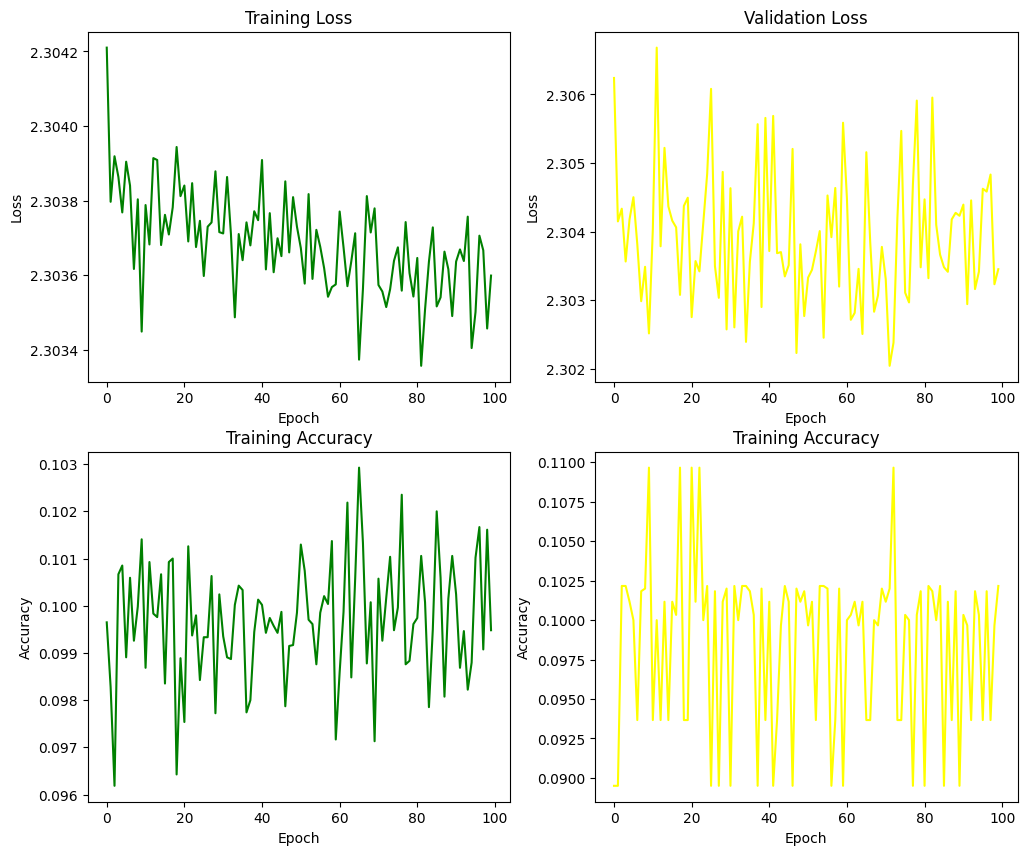

In [8]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")

**Solution to Gradient Vanishing**
<hr>

#**Weight Increasing**

**Case-study-1: std=1.0**

In [10]:
class MLP(nn.Module):
  def __init__(self,input_dims,hidden_dims, output_dims):
    super().__init__()
    self.layer1 = nn.Linear(input_dims,hidden_dims)
    self.layer2 = nn.Linear(hidden_dims,hidden_dims)
    self.layer3 = nn.Linear(hidden_dims,hidden_dims)
    self.layer4 = nn.Linear(hidden_dims,hidden_dims)
    self.layer5 = nn.Linear(hidden_dims,hidden_dims)
    self.layer6 = nn.Linear(hidden_dims,hidden_dims)
    self.layer7 = nn.Linear(hidden_dims,hidden_dims)
    self.output = nn.Linear(hidden_dims,output_dims)

    for module in self.modules():
      if isinstance(module,nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=1.0)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
    x = nn.Flatten()(x)
    x = self.layer1(x)
    x = nn.Sigmoid()(x)
    x = self.layer2(x)
    x = nn.Sigmoid()(x)
    x = self.layer3(x)
    x = nn.Sigmoid()(x)
    x = self.layer4(x)
    x = nn.Sigmoid()(x)
    x = self.layer5(x)
    x = nn.Sigmoid()(x)
    x = self.layer6(x)
    x = nn.Sigmoid()(x)
    x = self.layer7(x)
    x = nn.Sigmoid()(x)
    out = self.output(x)
    return out
input_dims = 784
hidden_dims = 128
output_dims = 10
lr = 1e-2
model = MLP(
    input_dims,
    hidden_dims,
    output_dims
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=lr)


In [11]:
epochs = 50
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader, val_loader,epochs)

EPOCH 1/50, Train_Loss:1.6667, Train_Acc: 0.4295, Validation Loss : 1.2791, Validation Accuracy: 0.5390
EPOCH 2/50, Train_Loss:1.1479, Train_Acc: 0.5871, Validation Loss : 1.0831, Validation Accuracy: 0.6213
EPOCH 3/50, Train_Loss:1.0076, Train_Acc: 0.6409, Validation Loss : 0.9976, Validation Accuracy: 0.6487
EPOCH 4/50, Train_Loss:0.9259, Train_Acc: 0.6699, Validation Loss : 0.9382, Validation Accuracy: 0.6717
EPOCH 5/50, Train_Loss:0.8681, Train_Acc: 0.6898, Validation Loss : 0.8903, Validation Accuracy: 0.6880
EPOCH 6/50, Train_Loss:0.8249, Train_Acc: 0.7045, Validation Loss : 0.8589, Validation Accuracy: 0.7008
EPOCH 7/50, Train_Loss:0.7908, Train_Acc: 0.7158, Validation Loss : 0.8339, Validation Accuracy: 0.7040
EPOCH 8/50, Train_Loss:0.7631, Train_Acc: 0.7263, Validation Loss : 0.8120, Validation Accuracy: 0.7152
EPOCH 9/50, Train_Loss:0.7406, Train_Acc: 0.7321, Validation Loss : 0.7937, Validation Accuracy: 0.7177
EPOCH 10/50, Train_Loss:0.7213, Train_Acc: 0.7400, Validation Lo

Text(0.5, 1.0, 'Training Accuracy')

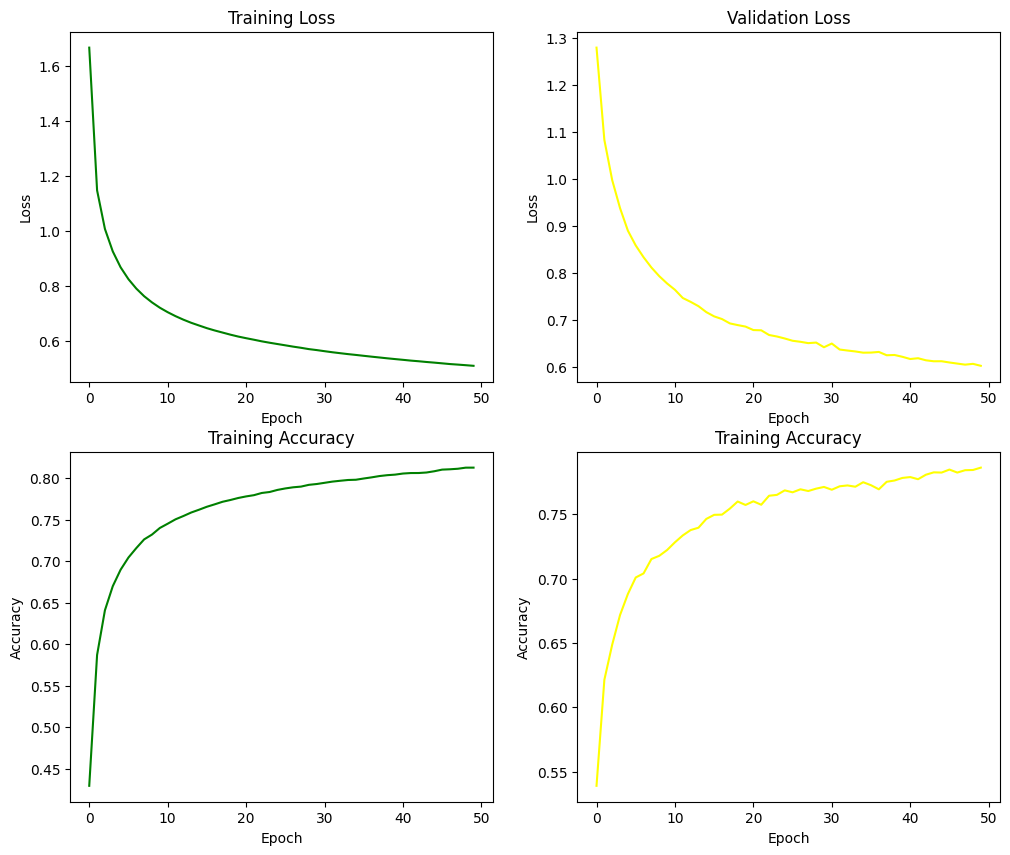

In [12]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")

**Case-study-2: std=10.0**

In [13]:
class MLP(nn.Module):
  def __init__(self,input_dims,hidden_dims, output_dims):
    super().__init__()
    self.layer1 = nn.Linear(input_dims,hidden_dims)
    self.layer2 = nn.Linear(hidden_dims,hidden_dims)
    self.layer3 = nn.Linear(hidden_dims,hidden_dims)
    self.layer4 = nn.Linear(hidden_dims,hidden_dims)
    self.layer5 = nn.Linear(hidden_dims,hidden_dims)
    self.layer6 = nn.Linear(hidden_dims,hidden_dims)
    self.layer7 = nn.Linear(hidden_dims,hidden_dims)
    self.output = nn.Linear(hidden_dims,output_dims)

    for module in self.modules():
      if isinstance(module,nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=1.0)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
    x = nn.Flatten()(x)
    x = self.layer1(x)
    x = nn.Sigmoid()(x)
    x = self.layer2(x)
    x = nn.Sigmoid()(x)
    x = self.layer3(x)
    x = nn.Sigmoid()(x)
    x = self.layer4(x)
    x = nn.Sigmoid()(x)
    x = self.layer5(x)
    x = nn.Sigmoid()(x)
    x = self.layer6(x)
    x = nn.Sigmoid()(x)
    x = self.layer7(x)
    x = nn.Sigmoid()(x)
    out = self.output(x)
    return out
input_dims = 784
hidden_dims = 128
output_dims = 10
lr = 1e-2

model = MLP(
    input_dims,
    hidden_dims,
    output_dims
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=lr)


In [14]:
epochs = 50
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader, val_loader,epochs)

EPOCH 1/50, Train_Loss:1.9345, Train_Acc: 0.4035, Validation Loss : 1.2840, Validation Accuracy: 0.5353
EPOCH 2/50, Train_Loss:1.1449, Train_Acc: 0.5816, Validation Loss : 1.0786, Validation Accuracy: 0.6072
EPOCH 3/50, Train_Loss:1.0014, Train_Acc: 0.6311, Validation Loss : 0.9833, Validation Accuracy: 0.6357
EPOCH 4/50, Train_Loss:0.9234, Train_Acc: 0.6592, Validation Loss : 0.9213, Validation Accuracy: 0.6605
EPOCH 5/50, Train_Loss:0.8715, Train_Acc: 0.6780, Validation Loss : 0.8813, Validation Accuracy: 0.6768
EPOCH 6/50, Train_Loss:0.8328, Train_Acc: 0.6935, Validation Loss : 0.8457, Validation Accuracy: 0.6875
EPOCH 7/50, Train_Loss:0.8023, Train_Acc: 0.7060, Validation Loss : 0.8146, Validation Accuracy: 0.7035
EPOCH 8/50, Train_Loss:0.7781, Train_Acc: 0.7151, Validation Loss : 0.7943, Validation Accuracy: 0.7080
EPOCH 9/50, Train_Loss:0.7580, Train_Acc: 0.7215, Validation Loss : 0.7775, Validation Accuracy: 0.7162
EPOCH 10/50, Train_Loss:0.7407, Train_Acc: 0.7278, Validation Lo

Text(0.5, 1.0, 'Training Accuracy')

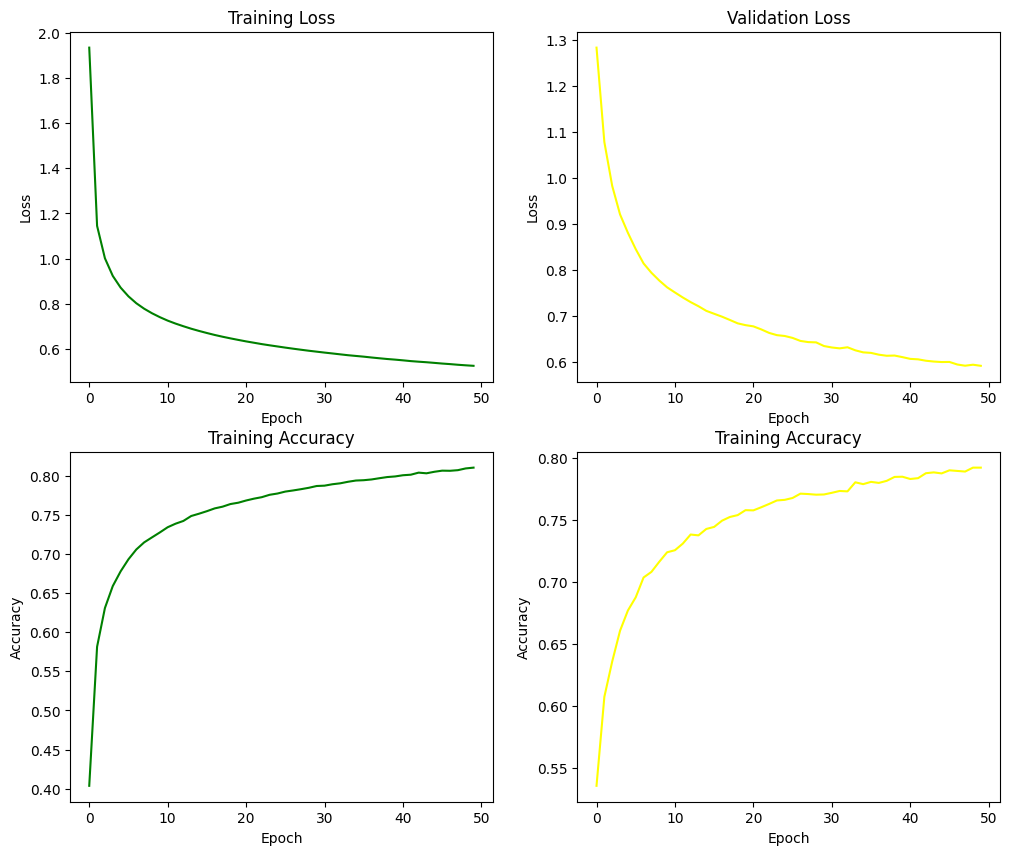

In [15]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")

#**Better Activation**

In [16]:
class MLP(nn.Module):
  def __init__(self,input_dims,hidden_dims, output_dims):
    super().__init__()
    self.layer1 = nn.Linear(input_dims,hidden_dims)
    self.layer2 = nn.Linear(hidden_dims,hidden_dims)
    self.layer3 = nn.Linear(hidden_dims,hidden_dims)
    self.layer4 = nn.Linear(hidden_dims,hidden_dims)
    self.layer5 = nn.Linear(hidden_dims,hidden_dims)
    self.layer6 = nn.Linear(hidden_dims,hidden_dims)
    self.layer7 = nn.Linear(hidden_dims,hidden_dims)
    self.output = nn.Linear(hidden_dims,output_dims)

    for module in self.modules():
      if isinstance(module,nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=1.0)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
    x = nn.Flatten()(x)
    x = self.layer1(x)
    x = nn.ReLU()(x)
    x = self.layer2(x)
    x = nn.ReLU()(x)
    x = self.layer3(x)
    x = nn.ReLU()(x)
    x = self.layer4(x)
    x = nn.ReLU()(x)
    x = self.layer5(x)
    x = nn.ReLU()(x)
    x = self.layer6(x)
    x = nn.ReLU()(x)
    x = self.layer7(x)
    x = nn.ReLU()(x)
    out = self.output(x)
    return out
input_dims = 784
hidden_dims = 128
output_dims = 10
lr = 1e-2
model = MLP(
    input_dims,
    hidden_dims,
    output_dims
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=lr)


In [17]:
epochs = 50
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader, val_loader,epochs)

EPOCH 1/50, Train_Loss:nan, Train_Acc: 0.0990, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 2/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 3/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 4/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 5/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 6/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 7/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 8/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 9/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 10/50, Train_Loss:nan, Train_Acc: 0.0989, Validation Loss : nan, Validation Accuracy: 0.1097
EPOCH 11/50, Train_

Text(0.5, 1.0, 'Training Accuracy')

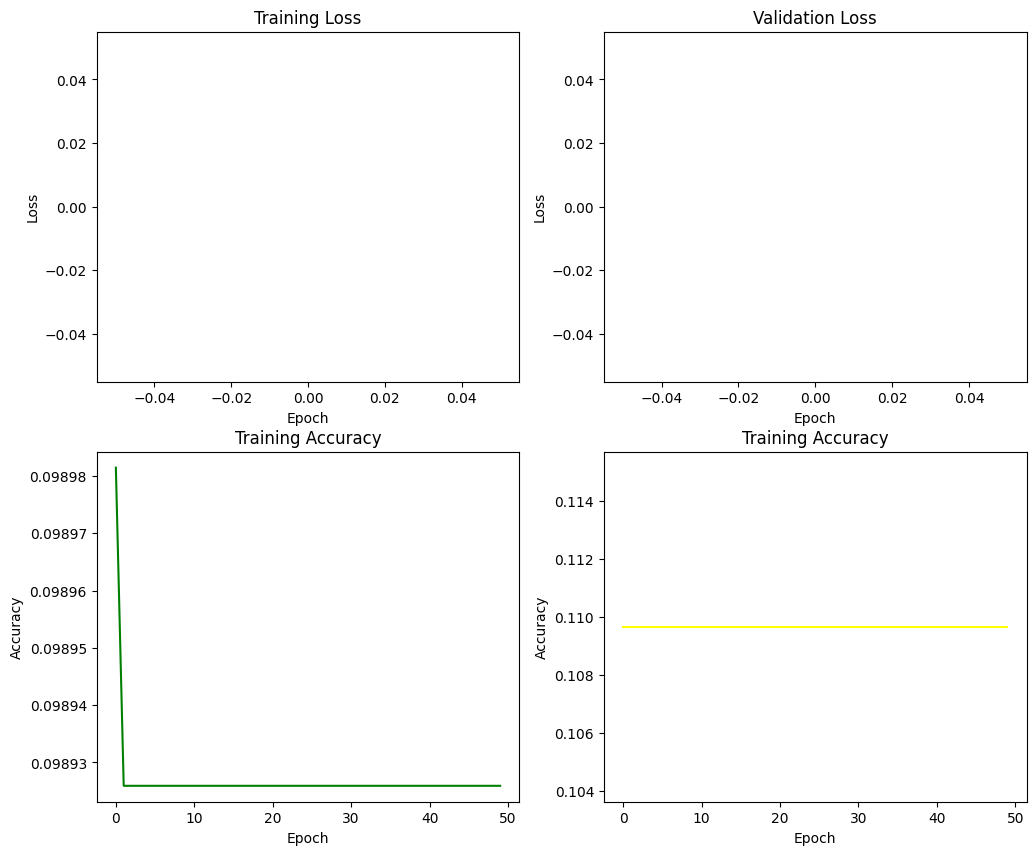

In [18]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")

#**Better Optimizer**

In [19]:
class MLP(nn.Module):
  def __init__(self,input_dims,hidden_dims, output_dims):
    super().__init__()
    self.layer1 = nn.Linear(input_dims,hidden_dims)
    self.layer2 = nn.Linear(hidden_dims,hidden_dims)
    self.layer3 = nn.Linear(hidden_dims,hidden_dims)
    self.layer4 = nn.Linear(hidden_dims,hidden_dims)
    self.layer5 = nn.Linear(hidden_dims,hidden_dims)
    self.layer6 = nn.Linear(hidden_dims,hidden_dims)
    self.layer7 = nn.Linear(hidden_dims,hidden_dims)
    self.output = nn.Linear(hidden_dims,output_dims)

    for module in self.modules():
      if isinstance(module,nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=0.05)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
    x = nn.Flatten()(x)
    x = self.layer1(x)
    x = nn.Sigmoid()(x)
    x = self.layer2(x)
    x = nn.Sigmoid()(x)
    x = self.layer3(x)
    x = nn.Sigmoid()(x)
    x = self.layer4(x)
    x = nn.Sigmoid()(x)
    x = self.layer5(x)
    x = nn.Sigmoid()(x)
    x = self.layer6(x)
    x = nn.Sigmoid()(x)
    x = self.layer7(x)
    x = nn.Sigmoid()(x)
    out = self.output(x)
    return out
input_dims = 784
hidden_dims = 128
output_dims = 10
lr = 1e-2

model = MLP(
    input_dims,
    hidden_dims,
    output_dims
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=lr)


In [20]:
epochs = 50
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader, val_loader,epochs)

EPOCH 1/50, Train_Loss:2.3049, Train_Acc: 0.1012, Validation Loss : 2.3049, Validation Accuracy: 0.0937
EPOCH 2/50, Train_Loss:2.3035, Train_Acc: 0.1011, Validation Loss : 2.3027, Validation Accuracy: 0.1003
EPOCH 3/50, Train_Loss:2.3035, Train_Acc: 0.0998, Validation Loss : 2.3026, Validation Accuracy: 0.1097
EPOCH 4/50, Train_Loss:2.3036, Train_Acc: 0.0991, Validation Loss : 2.3032, Validation Accuracy: 0.1020
EPOCH 5/50, Train_Loss:2.3036, Train_Acc: 0.0987, Validation Loss : 2.3048, Validation Accuracy: 0.0997
EPOCH 6/50, Train_Loss:2.3035, Train_Acc: 0.1011, Validation Loss : 2.3028, Validation Accuracy: 0.1022
EPOCH 7/50, Train_Loss:2.3036, Train_Acc: 0.0979, Validation Loss : 2.3042, Validation Accuracy: 0.1020
EPOCH 8/50, Train_Loss:2.3035, Train_Acc: 0.0989, Validation Loss : 2.3043, Validation Accuracy: 0.1020
EPOCH 9/50, Train_Loss:2.3035, Train_Acc: 0.0974, Validation Loss : 2.3059, Validation Accuracy: 0.0895
EPOCH 10/50, Train_Loss:2.3037, Train_Acc: 0.0997, Validation Lo

Text(0.5, 1.0, 'Training Accuracy')

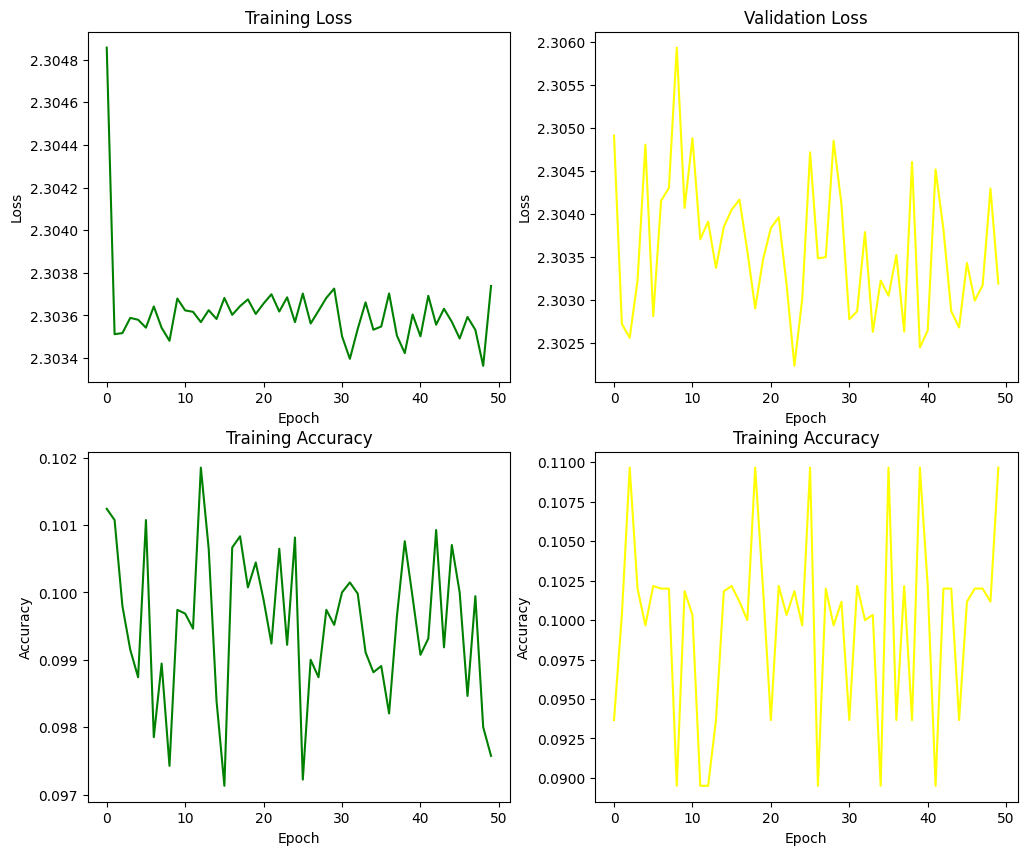

In [21]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")

#**Normalize Inside Network**

In [62]:
class MLP(nn.Module):
  def __init__(self,input_dims,hidden_dims, output_dims):
    super().__init__()
    self.hidden_dims = hidden_dims
    self.layer1 = nn.Linear(input_dims,hidden_dims)
    self.bn1 = nn.BatchNorm1d(self.hidden_dims)
    self.layer2 = nn.Linear(hidden_dims,hidden_dims)
    self.bn2 = nn.BatchNorm1d(self.hidden_dims)
    self.layer3 = nn.Linear(hidden_dims,hidden_dims)
    self.bn3 = nn.BatchNorm1d(self.hidden_dims)
    self.layer4 = nn.Linear(hidden_dims,hidden_dims)
    self.bn4 = nn.BatchNorm1d(self.hidden_dims)
    self.layer5 = nn.Linear(hidden_dims,hidden_dims)
    self.bn5 = nn.BatchNorm1d(self.hidden_dims)
    self.layer6 = nn.Linear(hidden_dims,hidden_dims)
    self.bn6 = nn.BatchNorm1d(self.hidden_dims)
    self.layer7 = nn.Linear(hidden_dims,hidden_dims)
    self.bn7 = nn.BatchNorm1d(self.hidden_dims)
    self.output = nn.Linear(hidden_dims,output_dims)

    for module in self.modules():
      if isinstance(module,nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=0.05)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
    x = nn.Flatten()(x)
    x = self.layer1(x)
    x = self.bn1(x)
    x = nn.Sigmoid()(x)
    x = self.layer2(x)
    x = self.bn2(x)
    x = nn.Sigmoid()(x)
    x = self.layer3(x)
    x = self.bn3(x)
    x = nn.Sigmoid()(x)
    x = self.layer4(x)
    x = self.bn4(x)
    x = nn.Sigmoid()(x)
    x = self.layer5(x)
    x = self.bn5(x)
    x = nn.Sigmoid()(x)
    x = self.layer6(x)
    x = self.bn6(x)
    x = nn.Sigmoid()(x)
    x = self.layer7(x)
    x = self.bn7(x)
    x = nn.Sigmoid()(x)
    out = self.output(x)
    return out
input_dims = 784
hidden_dims = 128
output_dims = 10
lr = 1e-2

model = MLP(
    input_dims,
    hidden_dims,
    output_dims
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=lr)


In [63]:
epochs = 50
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader, val_loader,epochs)

EPOCH 1/50, Train_Loss:0.6363, Train_Acc: 0.7754, Validation Loss : 0.5289, Validation Accuracy: 0.8095
EPOCH 2/50, Train_Loss:0.4793, Train_Acc: 0.8315, Validation Loss : 0.4349, Validation Accuracy: 0.8490
EPOCH 3/50, Train_Loss:0.4231, Train_Acc: 0.8493, Validation Loss : 0.4745, Validation Accuracy: 0.8178
EPOCH 4/50, Train_Loss:0.3870, Train_Acc: 0.8610, Validation Loss : 0.4171, Validation Accuracy: 0.8372
EPOCH 5/50, Train_Loss:0.3588, Train_Acc: 0.8712, Validation Loss : 0.3964, Validation Accuracy: 0.8645
EPOCH 6/50, Train_Loss:0.3389, Train_Acc: 0.8787, Validation Loss : 0.3716, Validation Accuracy: 0.8633
EPOCH 7/50, Train_Loss:0.3228, Train_Acc: 0.8824, Validation Loss : 0.3438, Validation Accuracy: 0.8753
EPOCH 8/50, Train_Loss:0.3059, Train_Acc: 0.8909, Validation Loss : 0.3798, Validation Accuracy: 0.8657
EPOCH 9/50, Train_Loss:0.2972, Train_Acc: 0.8900, Validation Loss : 0.3558, Validation Accuracy: 0.8772
EPOCH 10/50, Train_Loss:0.2838, Train_Acc: 0.8951, Validation Lo

In [ ]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")

#**Train layers separately(fine-tunning)**

In [41]:
class MLP_1layer(nn.Module):
  def __init__(self,input_dims,output_dims):
    super(MLP_1layer,self).__init__()
    self.layer1 = nn.Linear(input_dims,output_dims)
    for module in self.modules():
      if isinstance(module,nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=0.05)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
      x = nn.Flatten()(x)
      x = self.layer1(x)
      x = nn.Sigmoid()(x)
      return x
class MLP_2layer(nn.Module):
  def __init__(self,input_dims,output_dims):
    super(MLP_2layer,self).__init__()
    self.layer1 = nn.Linear(input_dims,output_dims)
    self.layer2 = nn.Linear(output_dims,output_dims)
    for module in self.modules():
      if isinstance(module,nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=0.05)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
      x = nn.Flatten()(x)
      x = self.layer1(x)
      x = nn.Sigmoid()(x)
      x =self.layer2(x)
      x = nn.Sigmoid()(x)
      return x

In [42]:
first = MLP_2layer(input_dims = 784,output_dims=128)
second = MLP_2layer(input_dims=128,output_dims=128)
third = MLP_2layer(input_dims=128,output_dims=128)
fourth = MLP_1layer(input_dims=128,output_dims=128)
epochs = 50
lr = 1e-2
criterion = nn.CrossEntropyLoss()

Stage 1-train the first component

In [43]:
model = nn.Sequential(
    first,
    nn.Linear(128,10)
).to(device)

optimizer = optim.SGD(model.parameters(),lr=lr)
train = fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:2.2892, Train_Acc: 0.1620, Validation Loss : 2.2765, Validation Accuracy: 0.0895
EPOCH 2/50, Train_Loss:2.2495, Train_Acc: 0.3009, Validation Loss : 2.2119, Validation Accuracy: 0.3900
EPOCH 3/50, Train_Loss:2.1238, Train_Acc: 0.4005, Validation Loss : 1.9959, Validation Accuracy: 0.4075
EPOCH 4/50, Train_Loss:1.8180, Train_Acc: 0.4389, Validation Loss : 1.6654, Validation Accuracy: 0.4968
EPOCH 5/50, Train_Loss:1.5416, Train_Acc: 0.5002, Validation Loss : 1.4477, Validation Accuracy: 0.5092
EPOCH 6/50, Train_Loss:1.3566, Train_Acc: 0.5504, Validation Loss : 1.2960, Validation Accuracy: 0.5665
EPOCH 7/50, Train_Loss:1.2264, Train_Acc: 0.5837, Validation Loss : 1.1895, Validation Accuracy: 0.5813
EPOCH 8/50, Train_Loss:1.1345, Train_Acc: 0.6044, Validation Loss : 1.1127, Validation Accuracy: 0.6138
EPOCH 9/50, Train_Loss:1.0654, Train_Acc: 0.6215, Validation Loss : 1.0547, Validation Accuracy: 0.6207
EPOCH 10/50, Train_Loss:1.0102, Train_Acc: 0.6347, Validation Lo

Stage 2 - Train the second component

In [44]:
for param in first.parameters():
  param.requires_grad = False

model = nn.Sequential(
    first,
    second,
    nn.Linear(128,10)
).to(device)

optimizer = optim.SGD(model.parameters(),lr=lr)
train =fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:2.3018, Train_Acc: 0.1101, Validation Loss : 2.3000, Validation Accuracy: 0.1908
EPOCH 2/50, Train_Loss:2.2958, Train_Acc: 0.1293, Validation Loss : 2.2923, Validation Accuracy: 0.1022
EPOCH 3/50, Train_Loss:2.2870, Train_Acc: 0.1641, Validation Loss : 2.2797, Validation Accuracy: 0.1735
EPOCH 4/50, Train_Loss:2.2683, Train_Acc: 0.2293, Validation Loss : 2.2527, Validation Accuracy: 0.2792
EPOCH 5/50, Train_Loss:2.2175, Train_Acc: 0.2800, Validation Loss : 2.1682, Validation Accuracy: 0.3708
EPOCH 6/50, Train_Loss:2.0696, Train_Acc: 0.3135, Validation Loss : 1.9508, Validation Accuracy: 0.3767
EPOCH 7/50, Train_Loss:1.8247, Train_Acc: 0.4022, Validation Loss : 1.7263, Validation Accuracy: 0.4212
EPOCH 8/50, Train_Loss:1.6524, Train_Acc: 0.4918, Validation Loss : 1.5969, Validation Accuracy: 0.5325
EPOCH 9/50, Train_Loss:1.5398, Train_Acc: 0.5277, Validation Loss : 1.4948, Validation Accuracy: 0.6013
EPOCH 10/50, Train_Loss:1.4296, Train_Acc: 0.5659, Validation Lo

Stage 3 - Update the current components (first model + second model)

In [45]:
for param in first.parameters():
  param.requires_grad = True
model  = nn.Sequential(
    first,
    second,
    nn.Linear(128,10)
).to(device)
optimizer = optim.SGD(model.parameters(),lr=lr)
train = fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:1.3943, Train_Acc: 0.6745, Validation Loss : 1.0408, Validation Accuracy: 0.7460
EPOCH 2/50, Train_Loss:0.9039, Train_Acc: 0.7758, Validation Loss : 0.8215, Validation Accuracy: 0.7717
EPOCH 3/50, Train_Loss:0.7532, Train_Acc: 0.7916, Validation Loss : 0.7203, Validation Accuracy: 0.7942
EPOCH 4/50, Train_Loss:0.6739, Train_Acc: 0.8005, Validation Loss : 0.6598, Validation Accuracy: 0.7988
EPOCH 5/50, Train_Loss:0.6245, Train_Acc: 0.8063, Validation Loss : 0.6223, Validation Accuracy: 0.7997
EPOCH 6/50, Train_Loss:0.5917, Train_Acc: 0.8110, Validation Loss : 0.5945, Validation Accuracy: 0.8077
EPOCH 7/50, Train_Loss:0.5686, Train_Acc: 0.8147, Validation Loss : 0.5760, Validation Accuracy: 0.8130
EPOCH 8/50, Train_Loss:0.5517, Train_Acc: 0.8175, Validation Loss : 0.5617, Validation Accuracy: 0.8130
EPOCH 9/50, Train_Loss:0.5383, Train_Acc: 0.8197, Validation Loss : 0.5513, Validation Accuracy: 0.8185
EPOCH 10/50, Train_Loss:0.5283, Train_Acc: 0.8217, Validation Lo

Stage 4 - Train the third component

In [48]:
for param in first.parameters():
  param.requires_grad = False
for param in second.parameters():
  param.requires_grad = False

model = nn.Sequential(
    first,
    second,
    third,
    nn.Linear(128,10)
).to(device)

optimizer = optim.SGD(model.parameters(),lr=lr)
train = fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:2.3008, Train_Acc: 0.1148, Validation Loss : 2.2951, Validation Accuracy: 0.1012
EPOCH 2/50, Train_Loss:2.2892, Train_Acc: 0.1616, Validation Loss : 2.2821, Validation Accuracy: 0.1967
EPOCH 3/50, Train_Loss:2.2689, Train_Acc: 0.2249, Validation Loss : 2.2523, Validation Accuracy: 0.3838
EPOCH 4/50, Train_Loss:2.2133, Train_Acc: 0.3060, Validation Loss : 2.1590, Validation Accuracy: 0.2913
EPOCH 5/50, Train_Loss:2.0414, Train_Acc: 0.3748, Validation Loss : 1.9031, Validation Accuracy: 0.4893
EPOCH 6/50, Train_Loss:1.7658, Train_Acc: 0.4722, Validation Loss : 1.6586, Validation Accuracy: 0.5612
EPOCH 7/50, Train_Loss:1.5661, Train_Acc: 0.5852, Validation Loss : 1.4903, Validation Accuracy: 0.5540
EPOCH 8/50, Train_Loss:1.3936, Train_Acc: 0.6329, Validation Loss : 1.3127, Validation Accuracy: 0.6263
EPOCH 9/50, Train_Loss:1.2183, Train_Acc: 0.6796, Validation Loss : 1.1526, Validation Accuracy: 0.7005
EPOCH 10/50, Train_Loss:1.0803, Train_Acc: 0.7090, Validation Lo

Stage 5 - Update the current model(first model + second model + third model)

In [49]:
for param in first.parameters():
  param.requires_grad = True
for param in second.parameters():
  param.requires_grad = True
model = nn.Sequential(
    first,
    second,
    third,
    nn.Linear(128,10)
).to(device)

optimizer = optim.SGD(model.parameters(),lr=lr)
train = fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:1.2951, Train_Acc: 0.7454, Validation Loss : 0.8999, Validation Accuracy: 0.8177
EPOCH 2/50, Train_Loss:0.7498, Train_Acc: 0.8330, Validation Loss : 0.6699, Validation Accuracy: 0.8307
EPOCH 3/50, Train_Loss:0.5997, Train_Acc: 0.8416, Validation Loss : 0.5800, Validation Accuracy: 0.8323
EPOCH 4/50, Train_Loss:0.5336, Train_Acc: 0.8448, Validation Loss : 0.5359, Validation Accuracy: 0.8380
EPOCH 5/50, Train_Loss:0.4975, Train_Acc: 0.8476, Validation Loss : 0.5108, Validation Accuracy: 0.8367
EPOCH 6/50, Train_Loss:0.4754, Train_Acc: 0.8492, Validation Loss : 0.4934, Validation Accuracy: 0.8420
EPOCH 7/50, Train_Loss:0.4604, Train_Acc: 0.8512, Validation Loss : 0.4819, Validation Accuracy: 0.8458
EPOCH 8/50, Train_Loss:0.4494, Train_Acc: 0.8527, Validation Loss : 0.4745, Validation Accuracy: 0.8435
EPOCH 9/50, Train_Loss:0.4410, Train_Acc: 0.8548, Validation Loss : 0.4655, Validation Accuracy: 0.8467
EPOCH 10/50, Train_Loss:0.4344, Train_Acc: 0.8555, Validation Lo

Stage 6 - Train the fourth component

In [50]:
for param in first.parameters():
  param.requires_grad = False
for param in second.parameters():
  param.requires_grad = False
for param in third.parameters():
  param.requires_grad = False
model = nn.Sequential(
    first,
    second,
    third,
    fourth,
    nn.Linear(128,10)
).to(device)

optimizer = optim.SGD(model.parameters(),lr=lr)
train = fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:2.1163, Train_Acc: 0.4647, Validation Loss : 1.8692, Validation Accuracy: 0.5782
EPOCH 2/50, Train_Loss:1.5678, Train_Acc: 0.7548, Validation Loss : 1.3135, Validation Accuracy: 0.8240
EPOCH 3/50, Train_Loss:1.1085, Train_Acc: 0.8516, Validation Loss : 0.9594, Validation Accuracy: 0.8555
EPOCH 4/50, Train_Loss:0.8230, Train_Acc: 0.8666, Validation Loss : 0.7405, Validation Accuracy: 0.8613
EPOCH 5/50, Train_Loss:0.6487, Train_Acc: 0.8723, Validation Loss : 0.6116, Validation Accuracy: 0.8623
EPOCH 6/50, Train_Loss:0.5463, Train_Acc: 0.8747, Validation Loss : 0.5376, Validation Accuracy: 0.8648
EPOCH 7/50, Train_Loss:0.4854, Train_Acc: 0.8761, Validation Loss : 0.4934, Validation Accuracy: 0.8640
EPOCH 8/50, Train_Loss:0.4476, Train_Acc: 0.8761, Validation Loss : 0.4655, Validation Accuracy: 0.8647
EPOCH 9/50, Train_Loss:0.4228, Train_Acc: 0.8771, Validation Loss : 0.4473, Validation Accuracy: 0.8655
EPOCH 10/50, Train_Loss:0.4058, Train_Acc: 0.8778, Validation Lo

Stage 7 - Update the current model(first model + second model + third model + fourth model)

In [51]:
for param in first.parameters():
  param.requires_grad = True
for param in second.parameters():
  param.requires_grad = True
for param in third.parameters():
  param.requires_grad = True
model = nn.Sequential(
    first,
    second,
    third,
    fourth,
    nn.Linear(128,10)
).to(device)

optimizer = optim.SGD(model.parameters(),lr=lr)
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:1.1980, Train_Acc: 0.7920, Validation Loss : 0.7492, Validation Accuracy: 0.8543
EPOCH 2/50, Train_Loss:0.5981, Train_Acc: 0.8669, Validation Loss : 0.5367, Validation Accuracy: 0.8592
EPOCH 3/50, Train_Loss:0.4711, Train_Acc: 0.8718, Validation Loss : 0.4708, Validation Accuracy: 0.8632
EPOCH 4/50, Train_Loss:0.4225, Train_Acc: 0.8737, Validation Loss : 0.4414, Validation Accuracy: 0.8623
EPOCH 5/50, Train_Loss:0.3984, Train_Acc: 0.8759, Validation Loss : 0.4286, Validation Accuracy: 0.8633
EPOCH 6/50, Train_Loss:0.3845, Train_Acc: 0.8769, Validation Loss : 0.4213, Validation Accuracy: 0.8598
EPOCH 7/50, Train_Loss:0.3752, Train_Acc: 0.8776, Validation Loss : 0.4101, Validation Accuracy: 0.8670
EPOCH 8/50, Train_Loss:0.3683, Train_Acc: 0.8784, Validation Loss : 0.4122, Validation Accuracy: 0.8645
EPOCH 9/50, Train_Loss:0.3633, Train_Acc: 0.8778, Validation Loss : 0.4021, Validation Accuracy: 0.8632
EPOCH 10/50, Train_Loss:0.3597, Train_Acc: 0.8794, Validation Lo

Text(0.5, 1.0, 'Training Accuracy')

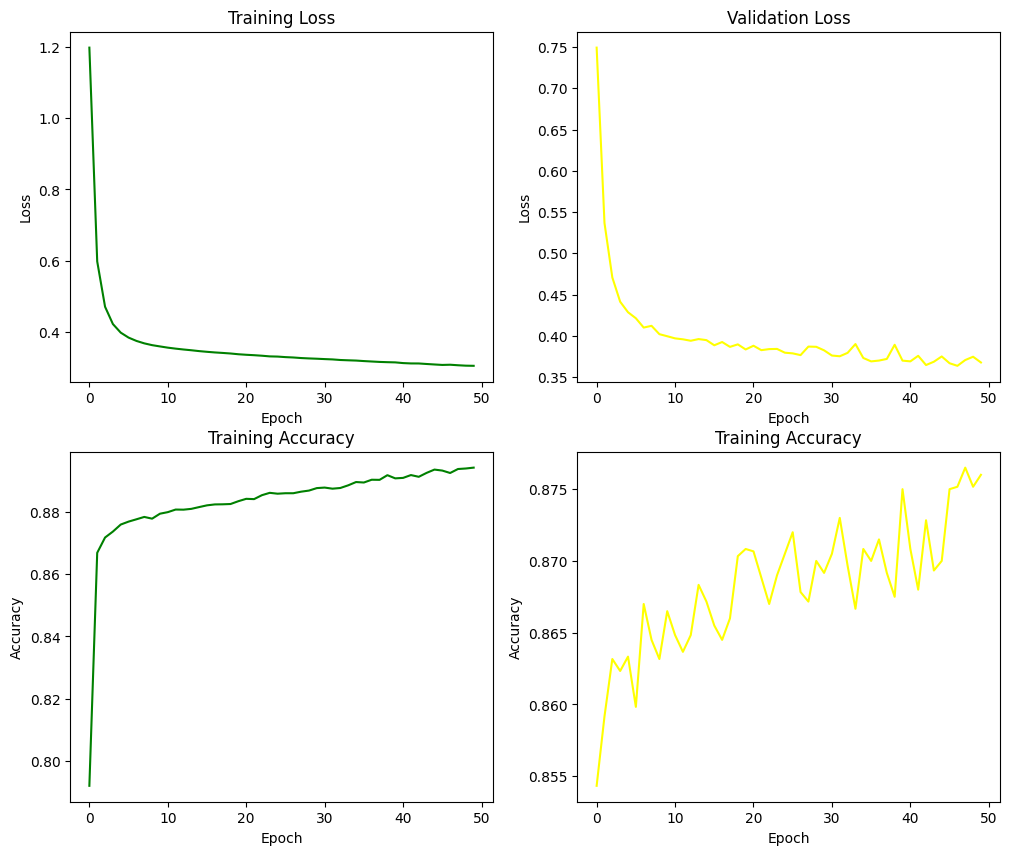

In [52]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")

#**Gradient Normalization**

In [64]:
class GradientNormalization(torch.autograd.Function):
  @staticmethod
  def forward(ctx,input):
    ctx.save_for_backward(input)
    return input
  def backward(ctx,grad_output):

    mean = torch.mean(grad_output)
    std = torch.std(grad_output)
    grad_input = (grad_output-mean)/(std+1e-6)
    return grad_input
class GradientNormalizationLayer(nn.Module):
  def __init__(self):
    super(GradientNormalizationLayer,self).__init__()
  def forward(self,x):
    return GradientNormalization.apply(x)

In [67]:
class MLP(nn.Module):
  def __init__(self,input_dims,hidden_dims, output_dims):
    super().__init__()
    self.hidden_dims = hidden_dims
    self.layer1 = nn.Linear(input_dims,hidden_dims)
    self.bn1 = nn.BatchNorm1d(self.hidden_dims)
    self.layer2 = nn.Linear(hidden_dims,hidden_dims)
    self.bn2 = nn.BatchNorm1d(self.hidden_dims)
    self.layer3 = nn.Linear(hidden_dims,hidden_dims)
    self.bn3 = nn.BatchNorm1d(self.hidden_dims)
    self.layer4 = nn.Linear(hidden_dims,hidden_dims)
    self.bn4 = nn.BatchNorm1d(self.hidden_dims)
    self.layer5 = nn.Linear(hidden_dims,hidden_dims)
    self.bn5 = nn.BatchNorm1d(self.hidden_dims)
    self.layer6 = nn.Linear(hidden_dims,hidden_dims)
    self.bn6 = nn.BatchNorm1d(self.hidden_dims)
    self.layer7 = nn.Linear(hidden_dims,hidden_dims)
    self.output = nn.Linear(hidden_dims,output_dims)
    self.gradient_norm = GradientNormalizationLayer()
    for module in self.modules():
      if isinstance(module,nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=0.05)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
    x = nn.Flatten()(x)
    x = self.layer1(x)
    x = self.gradient_norm(x)
    x = self.bn1(x)
    x = nn.ReLU()(x)
    x = self.layer2(x)
    x = self.gradient_norm(x)
    x = self.bn2(x)
    x = nn.ReLU()(x)
    x = self.layer3(x)
    x = self.gradient_norm(x)
    x = self.bn3(x)
    x = nn.ReLU()(x)
    x = self.layer4(x)
    x = self.gradient_norm(x)
    x = self.bn4(x)
    x = nn.ReLU()(x)
    x = self.layer5(x)
    x = self.gradient_norm(x)
    x = self.bn5(x)
    x = nn.ReLU()(x)
    x = self.layer6(x)
    x = self.gradient_norm(x)
    x = x = self.bn6(x)
    x = nn.ReLU()(x)
    x = self.layer7(x)
    x = self.gradient_norm(x)
    x = nn.ReLU()(x)
    out = self.output(x)
    return out
input_dims = 784
hidden_dims = 128
output_dims = 10
lr = 1e-2

model = MLP(
    input_dims,
    hidden_dims,
    output_dims
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=lr)

In [68]:
epochs = 50
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:0.6121, Train_Acc: 0.7924, Validation Loss : 0.5911, Validation Accuracy: 0.8022
EPOCH 2/50, Train_Loss:0.4539, Train_Acc: 0.8429, Validation Loss : 0.4267, Validation Accuracy: 0.8510
EPOCH 3/50, Train_Loss:0.4022, Train_Acc: 0.8605, Validation Loss : 0.3874, Validation Accuracy: 0.8625
EPOCH 4/50, Train_Loss:0.3720, Train_Acc: 0.8709, Validation Loss : 0.3848, Validation Accuracy: 0.8660
EPOCH 5/50, Train_Loss:0.3508, Train_Acc: 0.8764, Validation Loss : 0.4012, Validation Accuracy: 0.8613
EPOCH 6/50, Train_Loss:0.3346, Train_Acc: 0.8828, Validation Loss : 0.3866, Validation Accuracy: 0.8665
EPOCH 7/50, Train_Loss:0.3212, Train_Acc: 0.8872, Validation Loss : 0.3702, Validation Accuracy: 0.8720
EPOCH 8/50, Train_Loss:0.3091, Train_Acc: 0.8919, Validation Loss : 0.3437, Validation Accuracy: 0.8828
EPOCH 9/50, Train_Loss:0.2931, Train_Acc: 0.8976, Validation Loss : 0.3693, Validation Accuracy: 0.8758
EPOCH 10/50, Train_Loss:0.2834, Train_Acc: 0.8999, Validation Lo

Text(0.5, 1.0, 'Training Accuracy')

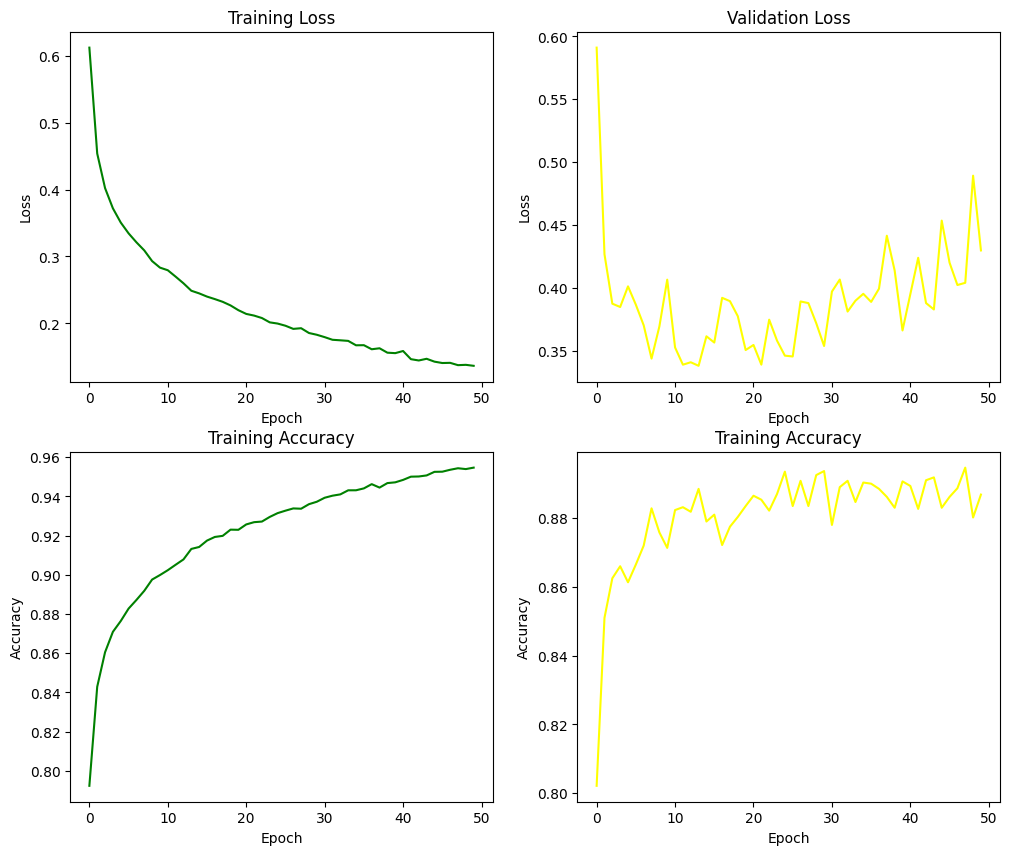

In [69]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")

# Skip Connection

In [70]:
class MLP(nn.Module):
  def __init__(self,input_dims,hidden_dims, output_dims):
    super().__init__()
    self.layer1 = nn.Linear(input_dims,hidden_dims)
    self.layer2 = nn.Linear(hidden_dims,hidden_dims)
    self.layer3 = nn.Linear(hidden_dims,hidden_dims)
    self.layer4 = nn.Linear(hidden_dims,hidden_dims)
    self.layer5 = nn.Linear(hidden_dims,hidden_dims)
    self.layer6 = nn.Linear(hidden_dims,hidden_dims)
    self.layer7 = nn.Linear(hidden_dims,hidden_dims)
    self.output = nn.Linear(hidden_dims,output_dims)

    for module in self.modules():
      if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight,mean=0.0,std=0.05)
        nn.init.constant_(module.bias,0.0)
  def forward(self,x):
    x = nn.Flatten()(x)
    x = self.layer1(x)
    x = nn.Sigmoid()(x)
    skip = x
    x = self.layer2(x)
    x = nn.Sigmoid()(x)
    x = self.layer3(x)
    x = nn.Sigmoid()(x)
    x = skip + x

    x = self.layer4(x)
    x = nn.Sigmoid()(x)
    skip = x
    x = self.layer5(x)
    x = nn.Sigmoid()(x)
    x = self.layer6(x)
    x = nn.Sigmoid()(x)
    x = self.layer7(x)
    x = nn.Sigmoid()(x)
    x = skip + x
    out = self.output(x)
    return out
input_dims = 784
hidden_dims = 128
output_dims = 10
lr = 1e-2

model = MLP(
    input_dims,
    hidden_dims,
    output_dims
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),lr=lr)

In [71]:
epochs = 50
train_loss_list,train_acc_list,val_loss_list,val_acc_list = fit(model,optimizer,criterion,device,train_loader,val_loader,epochs)

EPOCH 1/50, Train_Loss:2.3008, Train_Acc: 0.1128, Validation Loss : 2.2884, Validation Accuracy: 0.1020
EPOCH 2/50, Train_Loss:2.2764, Train_Acc: 0.1551, Validation Loss : 2.2552, Validation Accuracy: 0.1885
EPOCH 3/50, Train_Loss:2.2161, Train_Acc: 0.2536, Validation Loss : 2.1522, Validation Accuracy: 0.3377
EPOCH 4/50, Train_Loss:2.0158, Train_Acc: 0.3724, Validation Loss : 1.8527, Validation Accuracy: 0.3995
EPOCH 5/50, Train_Loss:1.6926, Train_Acc: 0.4661, Validation Loss : 1.5643, Validation Accuracy: 0.5302
EPOCH 6/50, Train_Loss:1.4505, Train_Acc: 0.5289, Validation Loss : 1.3691, Validation Accuracy: 0.5507
EPOCH 7/50, Train_Loss:1.2827, Train_Acc: 0.5761, Validation Loss : 1.2322, Validation Accuracy: 0.5980
EPOCH 8/50, Train_Loss:1.1702, Train_Acc: 0.5994, Validation Loss : 1.1419, Validation Accuracy: 0.6068
EPOCH 9/50, Train_Loss:1.0889, Train_Acc: 0.6153, Validation Loss : 1.0692, Validation Accuracy: 0.6227
EPOCH 10/50, Train_Loss:1.0258, Train_Acc: 0.6312, Validation Lo

Text(0.5, 1.0, 'Training Accuracy')

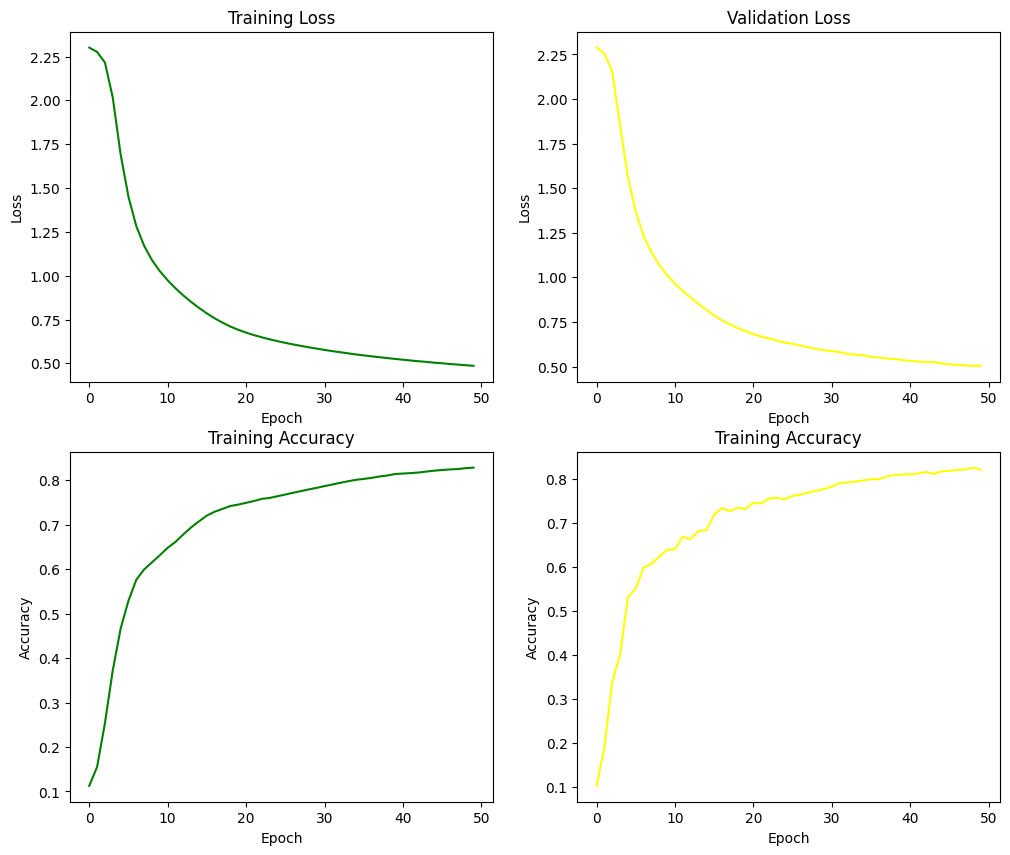

In [72]:
fig,ax = plt.subplots(2,2,figsize=(12,10))

ax[0,0].plot(train_loss_list,color="green")
ax[0,0].set(xlabel="Epoch",ylabel="Loss")
ax[0,0].set_title("Training Loss")

ax[0,1].plot(val_loss_list,color="yellow")
ax[0,1].set(xlabel="Epoch",ylabel="Loss")
ax[0,1].set_title("Validation Loss")

ax[1,0].plot(train_acc_list,color="green")
ax[1,0].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,0].set_title("Training Accuracy")

ax[1,1].plot(val_acc_list,color="yellow")
ax[1,1].set(xlabel="Epoch",ylabel="Accuracy")
ax[1,1].set_title("Training Accuracy")